## Cargar e inspeccionar los datos

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load the datasets
customer_profiles = pd.read_csv('../csv/customer_profiles.csv')
product_interactions = pd.read_csv('../csv/product_interactions.csv')
product_affinity = pd.read_csv('../csv/product_affinity.csv')

# Overview of data
print("Customer Profiles Overview:\n", customer_profiles.info())
print("\nProduct Interactions Overview:\n", product_interactions.info())
print("\nProduct Affinity Overview:\n", product_affinity.info())

# Show basic statistics
print("\nCustomer Profiles Statistics:\n", customer_profiles.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 13 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   customer_id           100000 non-null  int64  
 1   age                   100000 non-null  int64  
 2   gender                100000 non-null  object 
 3   income                100000 non-null  int64  
 4   location              100000 non-null  object 
 5   purchase_frequency    100000 non-null  float64
 6   avg_order_value       100000 non-null  float64
 7   preferred_category    100000 non-null  object 
 8   ingredients           100000 non-null  float64
 9   quality               100000 non-null  float64
 10  brand_loyalty         100000 non-null  float64
 11  discount_sensitivity  100000 non-null  float64
 12  clv                   100000 non-null  float64
dtypes: float64(7), int64(3), object(3)
memory usage: 9.9+ MB
Customer Profiles Overview:
 None
<class 'pandas

## Buscar los valores nulos y si hubiera, trabajar con ellos

In [5]:
# Contar valores nulos en cada columna
missing_values = customer_profiles.isnull().sum()

# Crear una tabla resumen
missing_summary = pd.DataFrame({
    "Column": missing_values.index,
    "Missing Values": missing_values.values,
    "Percentage Missing": (missing_values.values / len(customer_profiles)) * 100
})

# Mostrar solo columnas con valores nulos (o mostrar "0" si no hay ninguno)
if missing_summary["Missing Values"].sum() == 0:
    print("No missing values in the dataset!")
else:
    print(missing_summary)

No missing values in the dataset!


## Analizamos las distribuciones de las variables numéricas

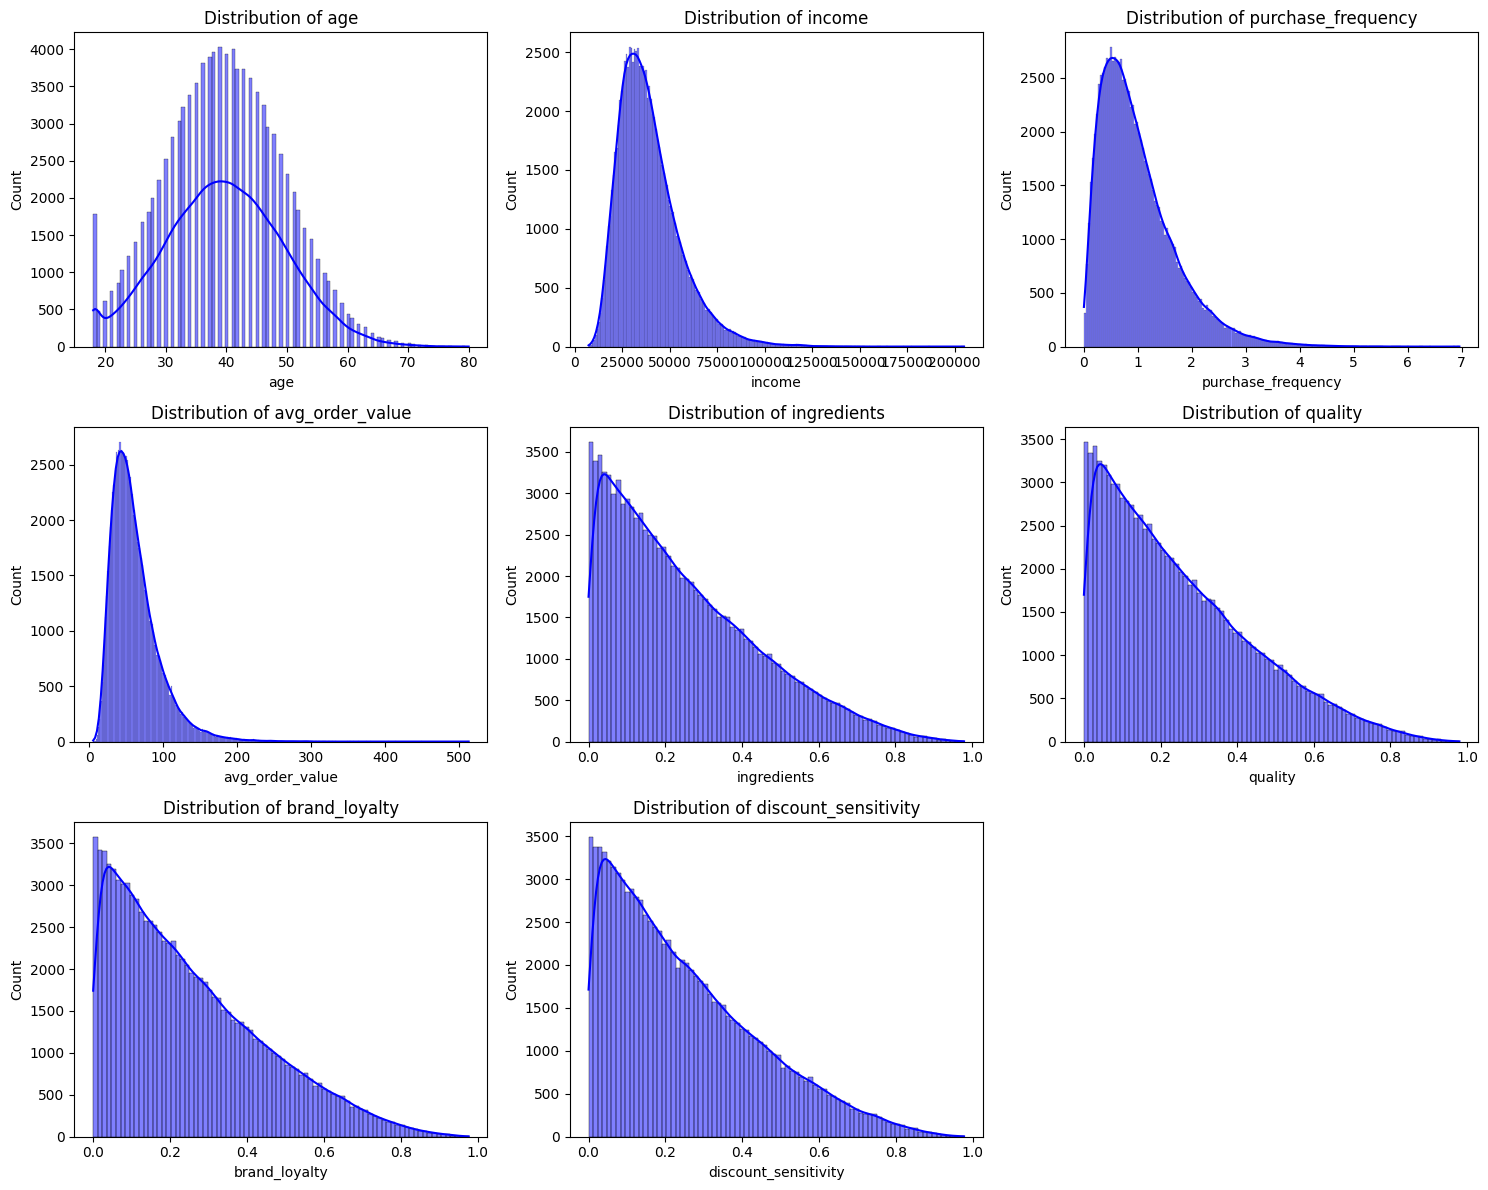

In [6]:
# Lista de columnas numéricas
numerical_cols = ["age", "income", "purchase_frequency", "avg_order_value", "ingredients", "quality", "brand_loyalty", "discount_sensitivity"]

# Determinar cuántos gráficos necesitamos (filas dinámicas)
num_cols = len(numerical_cols)
num_rows = (num_cols // 3) + (num_cols % 3 > 0)  # Calcula el número de filas necesarias

# Crear figura con subgráficos
fig, axes = plt.subplots(num_rows, 3, figsize=(15, num_rows * 4))
axes = axes.flatten()  # Asegurar que podamos acceder a los ejes como una lista

for i, col in enumerate(numerical_cols):
    sns.histplot(customer_profiles[col], kde=True, ax=axes[i], color="blue")
    axes[i].set_title(f"Distribution of {col}")

# Eliminar gráficos vacíos si hay menos de 9 variables
for j in range(i + 1, len(axes)):  
    fig.delaxes(axes[j])  

plt.tight_layout()
plt.show()

Estos gráficos representan la distribución de diversas características numéricas de los clientes, lo que nos ayuda a entender sus patrones de comportamiento y perfil de compra. 

- Edad (Age): La distribución muestra una concentración de clientes entre los 25 y 45 años, con un pico alrededor de los 35 años. Esto indica que la mayoría de los clientes están en una etapa adulta, lo que puede influir en sus decisiones de compra.

- Ingresos (Income): La distribución está sesgada hacia la derecha, lo que significa que la mayoría de los clientes tienen ingresos bajos o medianos, mientras que hay unos pocos con ingresos significativamente más altos. Esto sugiere que los productos y estrategias de precios deben adaptarse a un segmento con ingresos diversos.

- Frecuencia de compra (Purchase Frequency): La mayoría de los clientes compran con poca frecuencia, con una alta concentración cerca de valores bajos. Esto puede indicar que los clientes no son compradores recurrentes o que el ciclo de compra es más largo.

- Valor promedio del pedido (Avg Order Value): Similar a la frecuencia de compra, la mayoría de los pedidos tienen un valor bajo, aunque hay algunos pedidos con valores significativamente más altos. Esto sugiere que existen clientes que hacen compras ocasionales de alto valor.

- Ingredientes y Calidad (Ingredients & Quality): Ambas distribuciones muestran un patrón decreciente, indicando que la mayoría de los clientes prefieren productos con una menor calidad de ingredientes o con una calidad específica dentro de los niveles bajos a medios.

- Lealtad a la marca (Brand Loyalty): La distribución indica que la mayoría de los clientes tienen una lealtad baja a la marca. Esto sugiere que no están fuertemente comprometidos con una marca en particular y podrían ser influenciados por promociones o cambios en la oferta.

- Sensibilidad al descuento (Discount Sensitivity): La distribución muestra que la mayoría de los clientes tienen una alta sensibilidad a los descuentos, lo que significa que las estrategias de promociones y ofertas pueden ser efectivas para atraer compras.

La mayoría de los clientes tienen ingresos bajos a medianos y realizan compras poco frecuentes, por lo que las estrategias de fidelización podrían ser clave para aumentar la recurrencia.

Hay un grupo de clientes con compras de alto valor, lo que indica la posibilidad de segmentar ofertas para clientes premium.

La baja lealtad a la marca y la alta sensibilidad al descuento sugieren que las promociones y estrategias de marketing pueden ser fundamentales para retener clientes.

La distribución de calidad e ingredientes puede indicar que los clientes prefieren productos más simples o accesibles en lugar de opciones premium.

## Analizamos las distribuciones de las variables categóricas

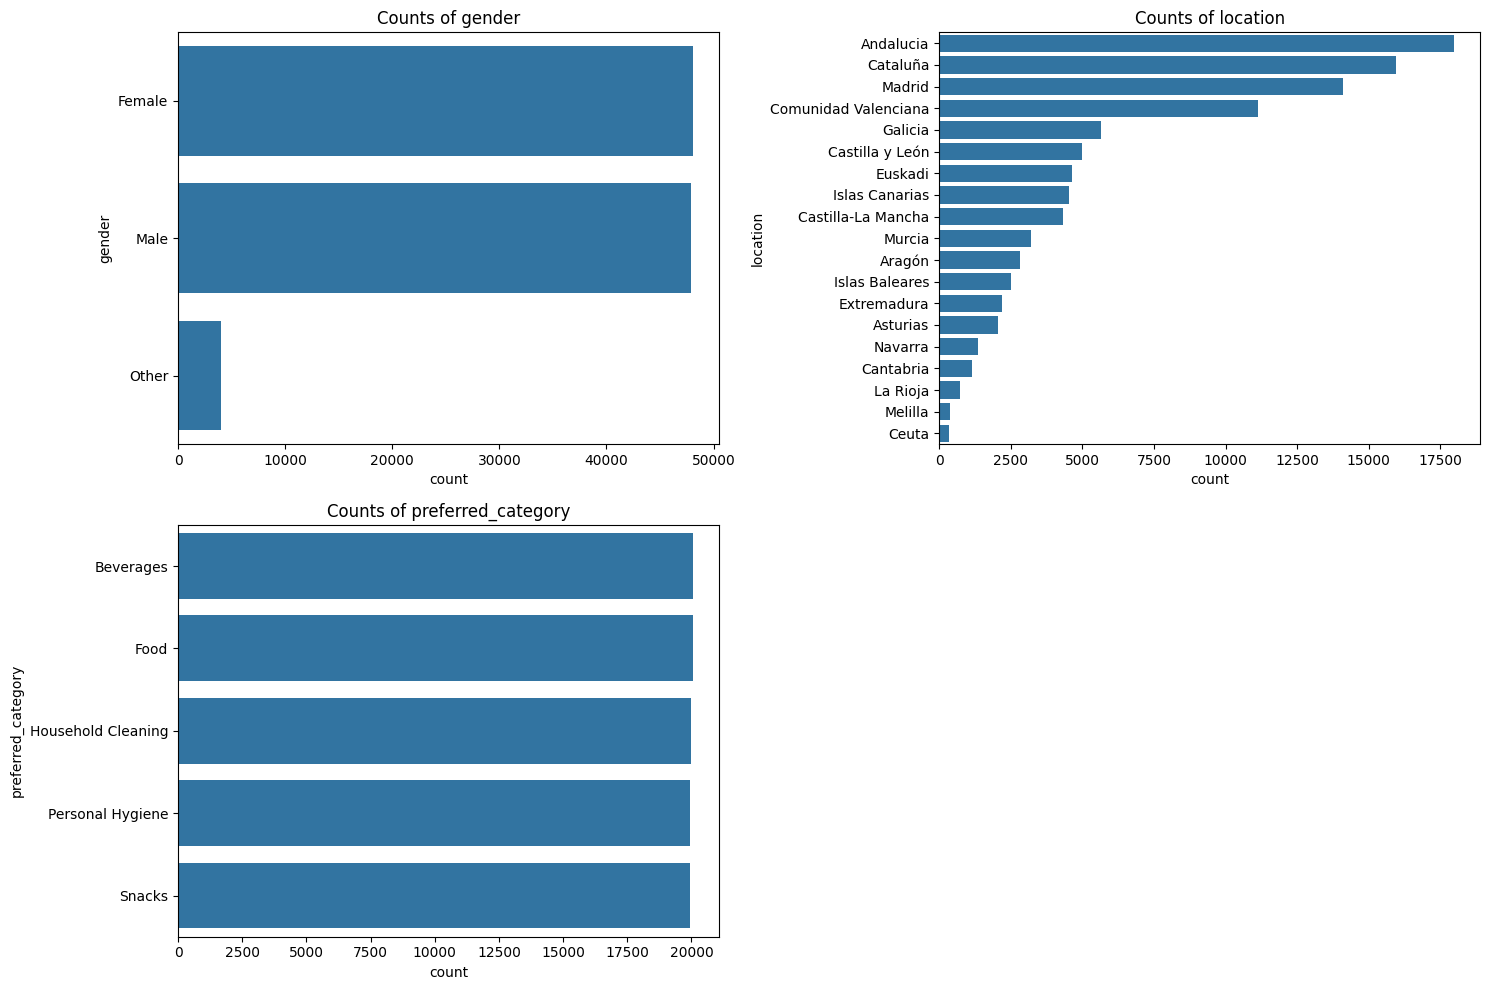

In [7]:
categorical_cols = ["gender", "location", "preferred_category"]

# Crear figura con 2 filas y 2 columnas (ajustado a número de variables)
fig, axes = plt.subplots(2, 2, figsize=(15, 10))  
axes = axes.flatten()  

for i, col in enumerate(categorical_cols):
    sns.countplot(y=customer_profiles[col], order=customer_profiles[col].value_counts().index, ax=axes[i])
    axes[i].set_title(f"Counts of {col}")

# Eliminar gráfico vacío si hay menos de 4 variables categóricas
for j in range(i + 1, len(axes)):  
    fig.delaxes(axes[j])  

plt.tight_layout()
plt.show()

Podemos observar que las variables categóricas estan distribuidas uniformemente en los gráficos de preferred category y gender. Y en la tabla location tenemos una distribución y mayor número de ejemplos en las grandes ciudades, y menor representación en las ciudades pequeñas.

## Detección de outliers

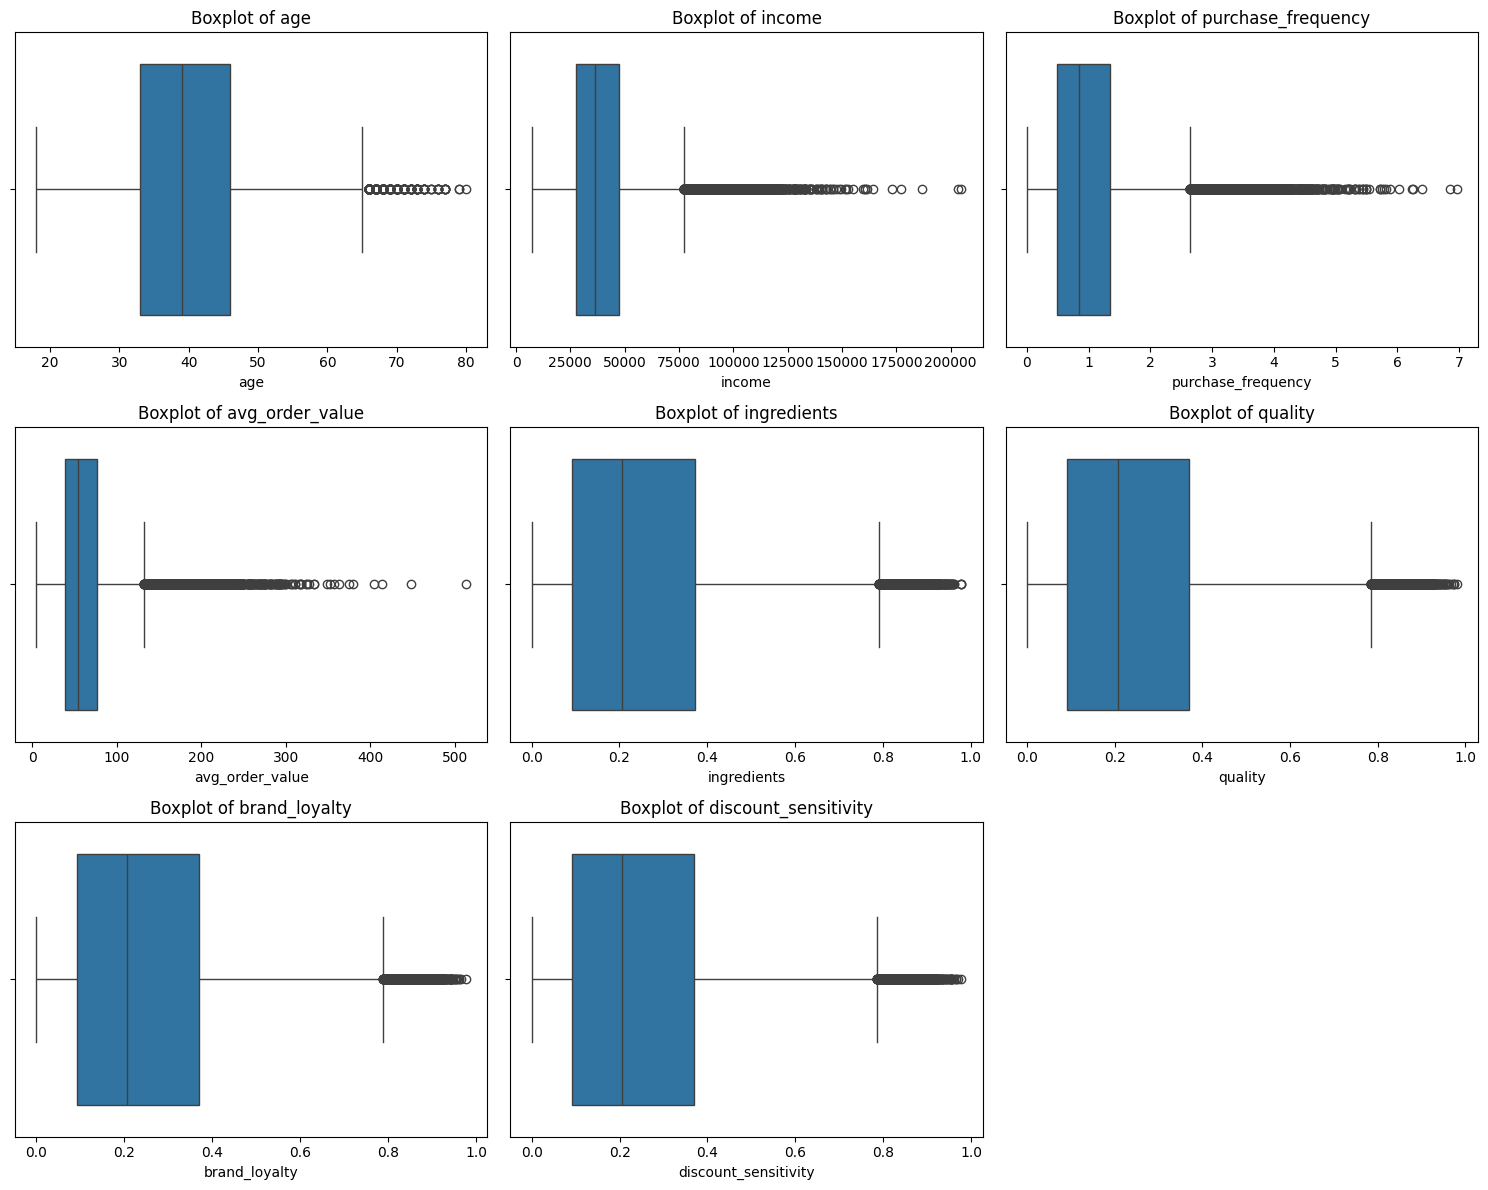

In [9]:
um_cols = len(numerical_cols)
num_rows = (num_cols // 3) + (num_cols % 3 > 0)  # Calcula el número de filas necesarias

# Crear figura con subgráficos
fig, axes = plt.subplots(num_rows, 3, figsize=(15, num_rows * 4))
axes = axes.flatten()  # Asegurar que podamos acceder a los ejes como una lista

# Generar los boxplots
for i, col in enumerate(numerical_cols):
    sns.boxplot(x=customer_profiles[col], ax=axes[i])
    axes[i].set_title(f"Boxplot of {col}")

# Eliminar gráficos vacíos si hay menos de 6 variables
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

- Estos gráficos muestran la distribución de las variables numéricas y resaltan los valores atípicos.
- Se observan muchos valores atípicos en ingresos, valor promedio de pedido y frecuencia de compra, lo que indica la presencia de clientes con comportamientos de compra extremos.
- La edad está bastante concentrada entre los 30 y 50 años, sin grandes valores atípicos.
- La variable de lealtad a la marca y sensibilidad al descuento presentan un sesgo hacia valores bajos, indicando que la mayoría de los clientes tienen una baja fidelidad a la marca.

Hay un pequeño grupo de clientes con ingresos muy altos y compras elevadas, pero la mayoría gasta poco y compra con poca frecuencia. Se podría segmentar a los clientes en grupos para diseñar estrategias personalizadas, como enfocarse en clientes con alta lealtad o aquellos más sensibles a descuentos.

## Visualización de relaciones entre variables

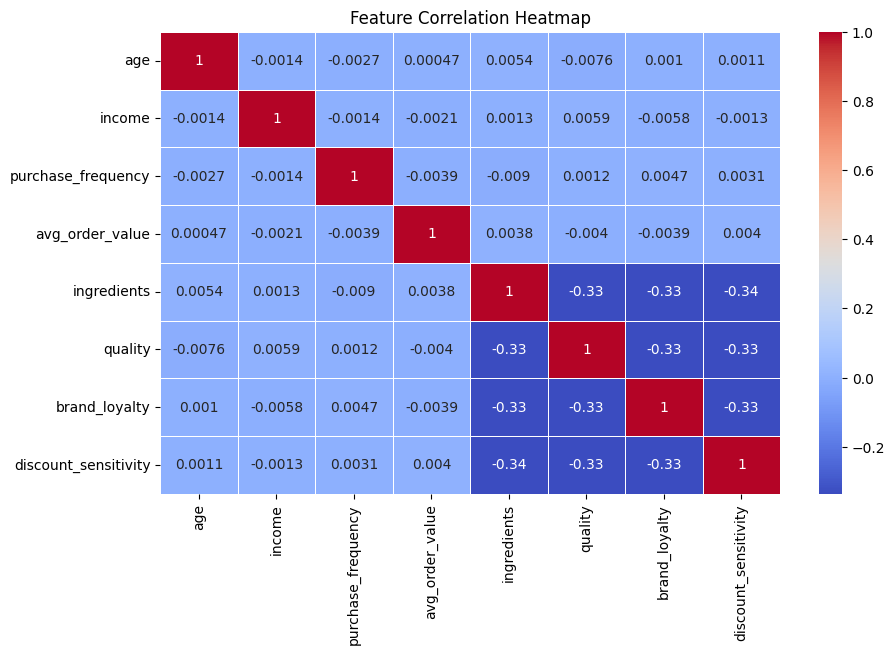

In [11]:
plt.figure(figsize=(10,6))
sns.heatmap(customer_profiles[numerical_cols].corr(), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

- Este gráfico muestra la correlación entre diferentes variables utilizando una escala de color.
- Valores cercanos a 1 indican una fuerte correlación positiva, mientras que valores cercanos a -1 indican una fuerte correlación negativa.
- En este caso, se observa que "ingredientes", "calidad", "lealtad a la marca" y "sensibilidad al descuento" están correlacionados negativamente entre sí (-0.33), lo que indica que los clientes que priorizan la calidad tienden a ser menos sensibles a los descuentos.
- No hay correlaciones fuertes entre ingresos, edad y otras variables, lo que sugiere que estas características son bastante independientes.